## Title: _____?

## Introduction

The gaming industry has increasingly relied on player analytics to understand user behaviour, personalize in-game experiences, and design effective marketing strategies. One area of particular interest is identifying what factors influence whether players choose to engage with optional game-related content, such as newsletters. Newsletters serve as an important communication channel for game developers, often used to share updates, promote new features, and foster long-term player engagement. Understanding which types of players are most likely to subscribe can help developers tailor outreach efforts and improve player retention.

The goal of this project is to investigate whether a player’s age and total playtime are associated with their likelihood of subscribing to the game’s newsletter. In other words, we ask:

### Research Question:
Can a player’s age and total playtime help explain patterns in who subscribes to the game’s newsletter?

To answer this question, we analyzed the players.csv dataset provided. This dataset contains anonymized information on 196 players, including demographic features and in-game behavioural metrics. The relevant variables for this study include:

age: The player’s age in years.

total_playtime: A numeric measure representing the player’s total hours or session-time spent in the game.

subscribed: A logical (TRUE/FALSE) indicator of whether the player is subscribed to the newsletter.

Additional variables such as session timestamps and player identifiers were included in the raw dataset but not directly used in the final analysis after exploratory review.

Before conducting modeling, we performed data cleaning and exploratory data analysis to understand variable distributions, assess potential limitations such as missing values or imbalance in the subscription variable, and generate visualizations that guide the methodological choices of the study. Because the response variable, subscribed, is binary, we use statistical modeling techniques suitable for classification tasks to evaluate whether age and playtime meaningfully predict subscription behaviour.

This analysis contributes to a broader understanding of player engagement by exploring whether simple, readily collected metrics (age and playtime) contain useful predictive patterns. If such relationships exist, they may inform targeted communication strategies, help identify under-engaged groups of players, and shape future data-driven decisions in game development and marketing.

## Methods and Results


In [1]:
library(tidyverse)

url <- "https://raw.githubusercontent.com/cassidoi/dsci-100-2025w1-group36-cassidy/refs/heads/main/players.csv"
players <- read_csv(url)

head(players)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


### Data Wrangling and Cleaning

Before conducting exploratory analysis, we prepared the dataset for modeling. 
The raw `players` data contains seven variables:

- `experience`: A categorical skill-level label (Amateur, Regular, Veteran, etc.)
- `subscribe`: A logical indicator of whether the player subscribed to the newsletter.
- `hashedEmail`: A unique, anonymized identifier for each player.
- `played_hours`: A numeric measure of total gameplay time.
- `name`: Player names (not analytically relevant).
- `gender`: Self-reported gender.
- `Age`: Player age in years.

Because our research question focuses on whether *age* and *total playtime* predict *subscription status*, we selected only the variables relevant to this relationship.  
We also standardized column names for readability, checked for missing values, and removed non-predictive identifiers such as `name` and `hashedEmail`.  


In [2]:
# Clean and wrangle the dataset
players_clean <- players |>
  rename(age = Age, subscribed = subscribe, playtime = played_hours) |>
  select(age, playtime, subscribed, experience, gender) |>
  drop_na()

# View the structure of the cleaned data
glimpse(players_clean)

Rows: 194
Columns: 5
$ age        <dbl> 9, 17, 17, 21, 21, 17, 19, 21, 47, 22, 23, 17, 25, 22, 17, …
$ playtime   <dbl> 30.3, 3.8, 0.0, 0.7, 0.1, 0.0, 0.0, 0.0, 0.1, 0.0, 1.6, 0.0…
$ subscribed <lgl> TRUE, TRUE, FALSE, TRUE, TRUE, TRUE, TRUE, FALSE, TRUE, TRU…
$ experience <chr> "Pro", "Veteran", "Veteran", "Amateur", "Regular", "Amateur…
$ gender     <chr> "Male", "Male", "Male", "Female", "Male", "Female", "Female…


### Exploratory Data Analysis: Summary Statistics

Before visualizing the data, we computed summary statistics to understand the basic structure of the dataset. Since our analysis focuses on whether age and total playtime help explain newsletter subscription behavior, the summary emphasizes these variables. 

We calculated overall measures of central tendency and spread for `age` and `playtime`, as well as the proportion of players who subscribed to the newsletter. To explore potential differences between groups, we also computed summary statistics for each variable by subscription status. These summaries help assess whether age or playtime appear to differ meaningfully between subscribed and unsubscribed players prior to formal modeling.


In [3]:
# Summary of numeric predictors
players_clean |>
  summarize(
    mean_age = mean(age),
    median_age = median(age),
    sd_age = sd(age),
    min_age = min(age),
    max_age = max(age),
    
    mean_playtime = mean(playtime),
    median_playtime = median(playtime),
    sd_playtime = sd(playtime),
    min_playtime = min(playtime),
    max_playtime = max(playtime)
  )

# Proportion of players subscribed
players_clean |>
  count(subscribed) |>
  mutate(prop = n / sum(n))

# Grouped summary by subscription status
players_clean |>
  group_by(subscribed) |>
  summarize(mean_age = mean(age),
    median_age = median(age),
    mean_playtime = mean(playtime),
    median_playtime = median(playtime),
    .groups = "drop")


mean_age,median_age,sd_age,min_age,max_age,mean_playtime,median_playtime,sd_playtime,min_playtime,max_playtime
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
21.13918,19,7.389687,9,58,5.904639,0.1,28.49793,0,223.1


subscribed,n,prop
<lgl>,<int>,<dbl>
FALSE,52,0.2680412
TRUE,142,0.7319588


subscribed,mean_age,median_age,mean_playtime,median_playtime
<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
FALSE,23.7500,21,0.5019231,0.0
TRUE,20.1831,19,7.8830986,0.1


### Exploratory Data Analysis: Visualizations

To better understand the distribution of the key predictors, we visualized the distributions of `age` and `playtime`, as well as the proportion of players who subscribed to the newsletter. These plots help identify skewness, group imbalance, and potential nonlinear patterns that may influence the modeling stage.


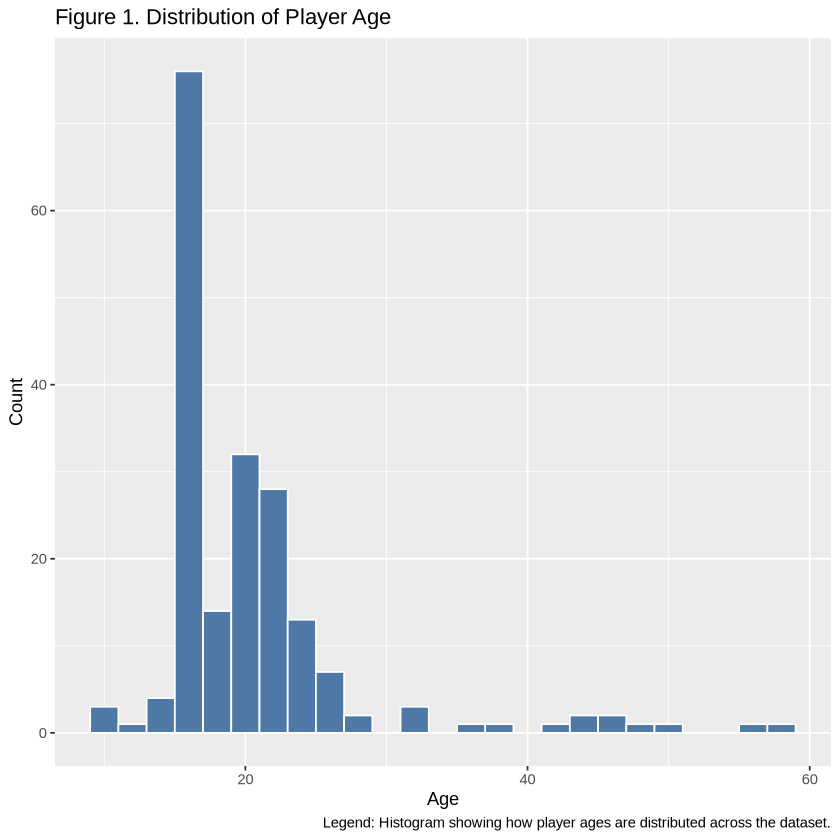

In [6]:
library(ggplot2)

ggplot(players_clean, aes(x = age)) +
  geom_histogram(binwidth = 2, fill = "#4E79A7", color = "white") +
  labs(
    title = "Figure 1. Distribution of Player Age",
    x = "Age",
    y = "Count",
    caption = "Legend: Histogram showing how player ages are distributed across the dataset."
  )


discussion should address limitations in the data, refer back to summary 